
===== TABLE 1: ENERGY (J) =====
GA        : 100.71
DE        : 140.59
WOA       : 143.46
E-WOA     : 51.52

===== TABLE 2: LIFETIME (Seconds) =====
GA        : 3971
DE        : 2845
WOA       : 2788
E-WOA     : 7763

===== TABLE 3: CONVERGENCE =====
GA        : 98
DE        : 87
WOA       : 94
E-WOA     : 99


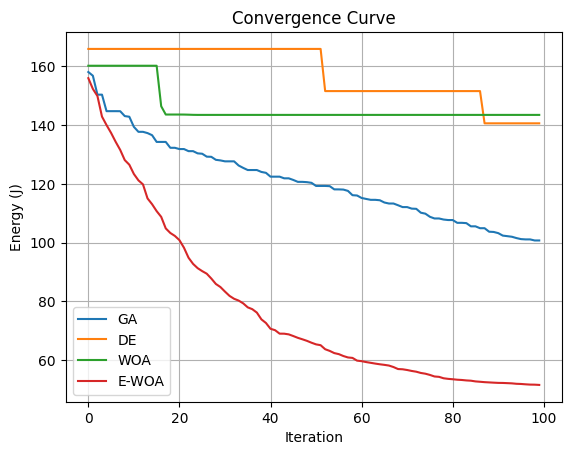

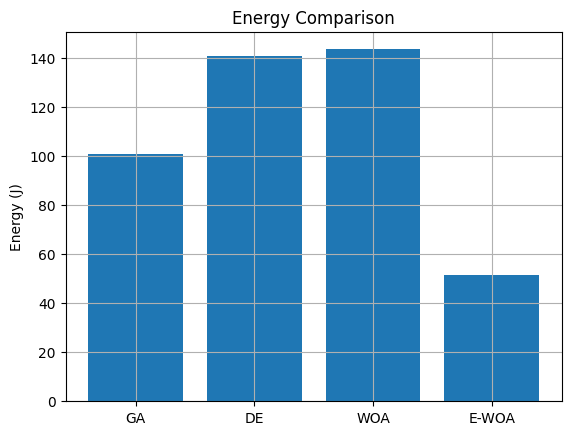

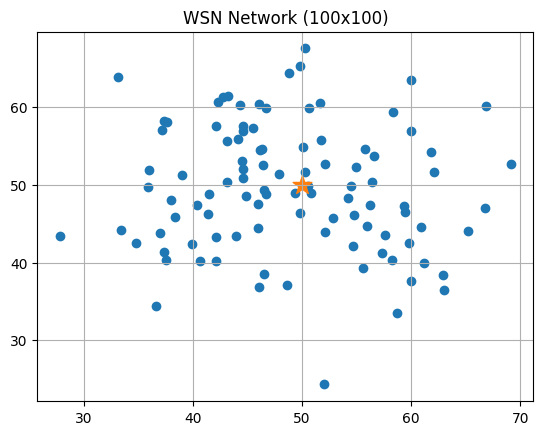

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# NETWORK PARAMETERS
AREA = 100
SINK = np.array([50, 50])
N_NODES = 100
INIT_ENERGY = 2.0
K = 4000

Eelec = 50e-9
Eamp = 100e-12

MAX_ITER = 100
POP_SIZE = 30
ROUNDS = 2000

# ENERGY MODEL
def energy_per_round(solution):
    nodes = solution.reshape(-1, 2)
    energy = 0
    for node in nodes:
        d = np.linalg.norm(node - SINK)
        energy += Eelec*K + Eamp*K*(d**2)
    return energy


def total_energy(solution):
    return energy_per_round(solution) * ROUNDS

# INITIAL POPULATION
def init_population():
    return np.random.uniform(0, AREA, (POP_SIZE, N_NODES*2))

# GA
def GA():
    pop = init_population()
    best = pop[0]
    best_fit = total_energy(best)
    conv_iter = 0
    curve = []

    for it in range(MAX_ITER):
        fits = [total_energy(p) for p in pop]

        if min(fits) < best_fit:
            best_fit = min(fits)
            best = pop[np.argmin(fits)].copy()
            conv_iter = it

        curve.append(best_fit)

        idx = np.argsort(fits)[:POP_SIZE//2]
        parents = pop[idx]

        children = []
        for i in range(len(parents)):
            p1 = parents[i]
            p2 = parents[random.randint(0, len(parents)-1)]
            cut = random.randint(0, len(p1)-1)
            child = np.concatenate([p1[:cut], p2[cut:]])
            child += np.random.normal(0, 1, child.shape)
            children.append(child)

        pop = np.vstack([parents, children])

    return best, best_fit, conv_iter, curve


# DE
def DE():
    pop = init_population()
    F, CR = 0.5, 0.7

    best = pop[0]
    best_fit = total_energy(best)
    conv_iter = 0
    curve = []

    for it in range(MAX_ITER):
        for i in range(POP_SIZE):
            a, b, c = pop[np.random.choice(POP_SIZE, 3, replace=False)]
            mutant = a + F*(b-c)

            trial = pop[i].copy()
            for j in range(len(trial)):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = total_energy(trial)
            f_target = total_energy(pop[i])

            if f_trial < f_target:
                pop[i] = trial

            if f_trial < best_fit:
                best_fit = f_trial
                best = trial.copy()
                conv_iter = it

        curve.append(best_fit)

    return best, best_fit, conv_iter, curve

# WOA
def WOA():
    pop = init_population()
    best = pop[0]
    best_fit = total_energy(best)
    conv_iter = 0
    curve = []

    for t in range(MAX_ITER):
        a = 2 - t*(2/MAX_ITER)

        for i in range(POP_SIZE):
            r = random.random()
            A = 2*a*r - a
            C = 2*r

            D = abs(C*best - pop[i])
            new = best - A*D

            f = total_energy(new)
            if f < best_fit:
                best = new.copy()
                best_fit = f
                conv_iter = t

            pop[i] = new

        curve.append(best_fit)

    return best, best_fit, conv_iter, curve

# IMPROVED E-WOA
def distance_weight(sol):
    nodes = sol.reshape(-1, 2)
    d = np.linalg.norm(nodes - SINK, axis=1)
    return 1/(1+np.mean(d))


def local_search(sol, sigma=0.5):
    candidate = sol + np.random.normal(0, sigma, sol.shape)
    candidate = np.clip(candidate, 0, AREA)
    if total_energy(candidate) < total_energy(sol):
        return candidate
    return sol


def E_WOA():
    pop = init_population()
    fitness = np.array([total_energy(p) for p in pop])

    best = pop[np.argmin(fitness)].copy()
    best_fit = np.min(fitness)

    conv_iter = 0
    curve = []

    for t in range(MAX_ITER):

        a = 2*(1 - (t/MAX_ITER)**2)
        sigma = 1.0*(1 - t/MAX_ITER)

        new_pop = []

        for i in range(POP_SIZE):
            Xi = pop[i].copy()

            A = 2*a*random.random()-a
            C = 2*random.random()
            p = random.random()

            w = distance_weight(Xi)

            if p < 0.5:
                if abs(A) < 1:
                    D = abs(C*best - Xi)
                    Xi_new = best - A*D*w
                else:
                    rand = pop[random.randint(0,POP_SIZE-1)]
                    D = abs(C*rand - Xi)
                    Xi_new = rand - A*D*w
            else:
                D = abs(best - Xi)
                l = random.uniform(-1,1)
                Xi_new = D*np.exp(l)*np.cos(2*np.pi*l) + best

            Xi_new += np.random.normal(0, sigma, Xi_new.shape)
            Xi_new = np.clip(Xi_new,0,AREA)

            if total_energy(Xi_new) < total_energy(Xi):
                new_pop.append(Xi_new)
            else:
                new_pop.append(Xi)

        pop = np.array(new_pop)
        fitness = np.array([total_energy(p) for p in pop])

        # elitism
        worst = np.argmax(fitness)
        pop[worst] = best
        fitness[worst] = best_fit

        # local search
        top = np.argsort(fitness)[:int(0.2*POP_SIZE)]
        for j in top:
            improved = local_search(pop[j], sigma)
            if total_energy(improved) < fitness[j]:
                pop[j] = improved
                fitness[j] = total_energy(improved)

        if np.min(fitness) < best_fit:
            best_fit = np.min(fitness)
            best = pop[np.argmin(fitness)].copy()
            conv_iter = t

        curve.append(best_fit)

    return best, best_fit, conv_iter, curve

# RUN ALL
algorithms = {"GA": GA, "DE": DE, "WOA": WOA, "E-WOA": E_WOA}

energy_results = {}
lifetime_results = {}
conv_results = {}
curves = {}

best_solution_final = None

for name, algo in algorithms.items():
    sol, E, conv, curve = algo()

    energy_results[name] = E
    lifetime_results[name] = int((INIT_ENERGY*N_NODES) / energy_per_round(sol))
    conv_results[name] = conv
    curves[name] = curve

    if name == "E-WOA":
        best_solution_final = sol

# TABLE OUTPUT
print("\n===== TABLE 1: ENERGY (J) =====")
for k in energy_results:
    print(f"{k:10s}: {energy_results[k]:.2f}")

print("\n===== TABLE 2: LIFETIME (Seconds) =====")
for k in lifetime_results:
    print(f"{k:10s}: {lifetime_results[k]}")

print("\n===== TABLE 3: CONVERGENCE =====")
for k in conv_results:
    print(f"{k:10s}: {conv_results[k]}")

# GRAPHS
plt.figure()
for k in curves:
    plt.plot(curves[k], label=k)
plt.legend()
plt.title("Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Energy (J)")
plt.grid()
plt.show()

plt.figure()
plt.bar(list(energy_results.keys()), list(energy_results.values()))
plt.title("Energy Comparison")
plt.ylabel("Energy (J)")
plt.grid()
plt.show()

# Network graph
nodes = best_solution_final.reshape(-1,2)
plt.figure()
plt.scatter(nodes[:,0], nodes[:,1])
plt.scatter(SINK[0], SINK[1], marker='*', s=200)
plt.title("WSN Network (100x100)")
plt.grid()
plt.show()